In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import plotly.graph_objects as go

from src.almgren_chriss import compute_kappa, almgren_chriss_trajectory
from src.simulator import simulate_one_path, monte_carlo_simulation
from src.data_loader import fetch_raw_data, avg_volume, volatility
from src.benchmarks import twap_schedule, vwap_schedule
from src.frontier import frontier_construction, frontier_plot

/Users/for_everyoung10/Documents/optimal-execution-simulator/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [9]:
raw_data = fetch_raw_data('TSM', '5m', start='2026-06-29', end='2026-07-08')
avg_vol = avg_volume(raw_data)
N = len(avg_vol)
print(N)

[*********************100%***********************]  1 of 1 completed

78


In [11]:
X = 10000
T = 1
N = len(avg_vol)
tau = T / N
eta, gamma = 1e-6, 1e-7
n_sims = 10000

sigma = volatility(raw_data, tau=tau, interval='5m')
S0 = raw_data['Close'].iloc[-1]

print(sigma, S0)

0.004060379514072324 432.6400146484375


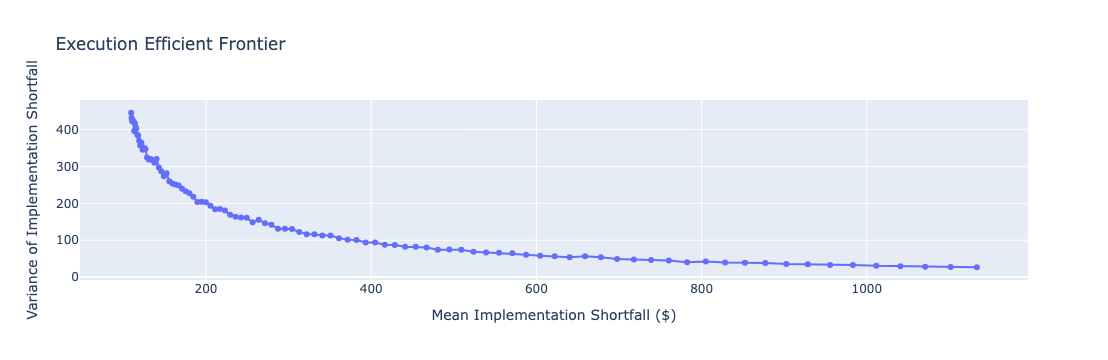

In [26]:
lambda_range_zoom = np.logspace(-1, 1.5, 100)  # narrower, targeting the steep transition
frontier_zoom = frontier_construction(X, T, N, sigma, eta, gamma, lambda_range_zoom, n_sims, S0)
frontier_plot(frontier_zoom)

In [27]:
selected_lambdas = [0.15023, 0.96571, 25.0605]

ac_results = {}
for lam in selected_lambdas:
    traj = almgren_chriss_trajectory(X, T, N, lam, sigma, eta, gamma)
    shares_traded = traj['shares_traded'].dropna().values
    IS_raw, IS_paired = monte_carlo_simulation(S0, shares_traded, sigma, eta, gamma, tau, n_sims)
    ac_results[lam] = {
        'trajectory': traj,
        'mean_cost': IS_paired['IS_paired'].mean(),
        'variance_cost': IS_raw['IS_raw'].var()
    }

In [28]:
twap_shares = twap_schedule(X, N)
twap_IS_raw, twap_IS_paired = monte_carlo_simulation(S0, twap_shares, sigma, eta, gamma, tau, n_sims)

twap_mean = twap_IS_paired['IS_paired'].mean()
twap_var = twap_IS_raw['IS_raw'].var()

In [29]:
vwap_shares = vwap_schedule(X, avg_vol['volume'].values)
vwap_IS_raw, vwap_IS_paired = monte_carlo_simulation(S0, vwap_shares, sigma, eta, gamma, tau, n_sims)

vwap_mean = vwap_IS_paired['IS_paired'].mean()
vwap_var = vwap_IS_raw['IS_raw'].var()

In [30]:
rows = []
for lam, res in ac_results.items():
    rows.append((f'AC (λ={lam:.2e})', res['mean_cost'], res['variance_cost']))
rows.append(('TWAP', twap_mean, twap_var))
rows.append(('VWAP', vwap_mean, vwap_var))

comparison_table = pd.DataFrame(rows, columns=['strategy', 'mean_cost', 'variance_cost'])
comparison_table

,strategy,mean_cost,variance_cost
0,AC (λ=1.50e-01),113.843723,399.118569
1,AC (λ=9.66e-01),205.361440,197.819274
2,AC (λ=2.51e+01),1011.478346,32.280096
3,TWAP,104.935897,531.575346
4,VWAP,172.512445,403.037394


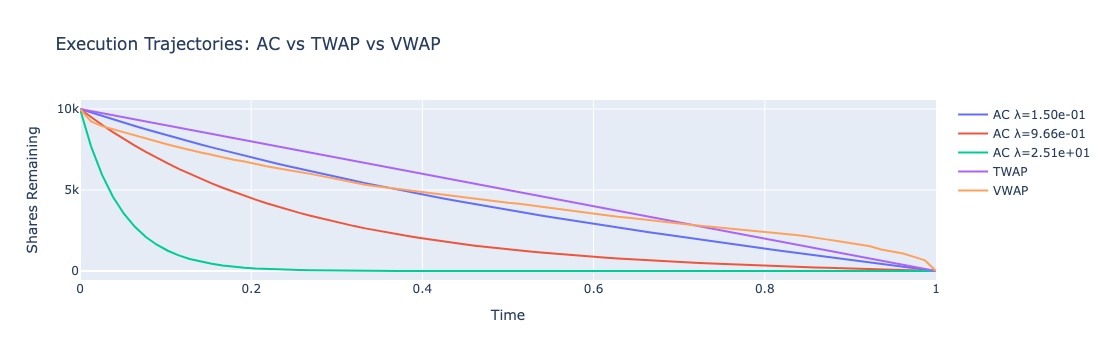

In [31]:
fig = go.Figure()

for lam, res in ac_results.items():
    fig.add_trace(go.Scatter(x=res['trajectory']['time'], y=res['trajectory']['shares_remaining'],
                              mode='lines', name=f'AC λ={lam:.2e}'))

twap_remaining = X - np.concatenate([[0], np.cumsum(twap_shares)])
vwap_remaining = X - np.concatenate([[0], np.cumsum(vwap_shares)])
time_axis = np.arange(N+1) * tau

fig.add_trace(go.Scatter(x=time_axis, y=twap_remaining, mode='lines', name='TWAP'))
fig.add_trace(go.Scatter(x=time_axis, y=vwap_remaining, mode='lines', name='VWAP'))

fig.update_layout(title='Execution Trajectories: AC vs TWAP vs VWAP',
                   xaxis_title='Time', yaxis_title='Shares Remaining')
fig.show()

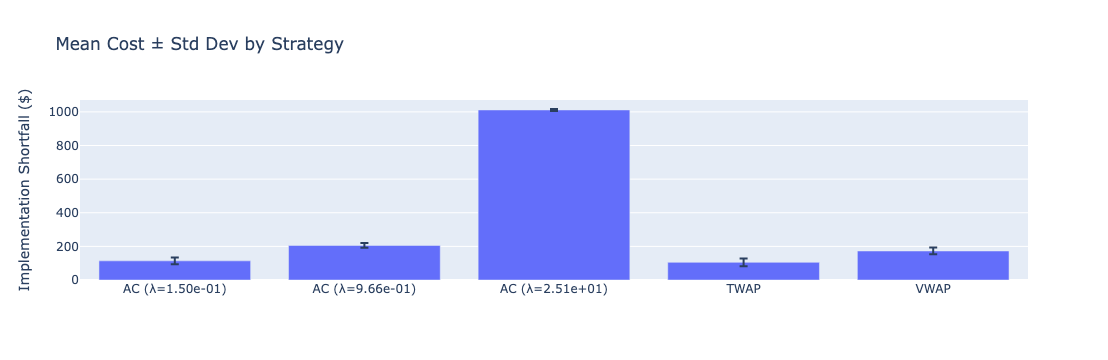

In [32]:
fig2 = go.Figure()
fig2.add_trace(go.Bar(
    x=comparison_table['strategy'],
    y=comparison_table['mean_cost'],
    error_y=dict(type='data', array=np.sqrt(comparison_table['variance_cost']))
))
fig2.update_layout(title='Mean Cost ± Std Dev by Strategy', yaxis_title='Implementation Shortfall ($)')
fig2.show()